In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, recall_score, make_scorer
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_parquet('train_processed.parquet')
imp_features = pd.read_csv('feature_importances.csv')
columns_to_keep = imp_features['feature'].tolist() + ['TARGET']
train_df_selected = train_df[train_df.columns[train_df.columns.isin(columns_to_keep)]]
X = train_df_selected.drop(columns=['TARGET'])
y = train_df_selected['TARGET']

In [3]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

In [5]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)

X_train_imp = pd.DataFrame(X_train_imp, columns=X_train.columns)
X_val_imp = pd.DataFrame(X_val_imp, columns=X_val.columns)
X_test_imp = pd.DataFrame(X_test_imp, columns=X_test.columns)

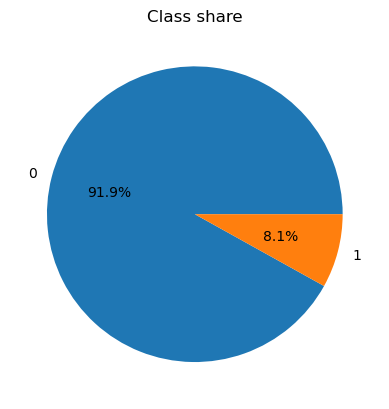

In [6]:
y_train.value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['0', '1'])
plt.title('Class share')
plt.ylabel('')
plt.show()

In [7]:
smote = SMOTE(random_state=42, sampling_strategy='minority')
X_train_res, y_train_res = smote.fit_resample(X_train_imp, y_train)

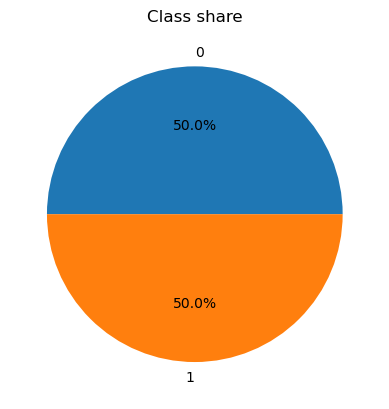

In [8]:
y_train_res.value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['0', '1'])
plt.title('Class share')
plt.ylabel('')
plt.show()

In [11]:
scorer = make_scorer(f1_score)
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'scale_pos_weight': [10, 15, 20, 25]
}
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
random_search = RandomizedSearchCV(
    xgb_base, param_dist_xgb, n_iter=20, cv=3, scoring=scorer,
    random_state=42, n_jobs=-1, verbose=1
)
random_search.fit(X_train_res, y_train_res)
best_xgb = random_search.best_estimator_
print("XGBoost parameters:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
XGBoost parameters: {'subsample': 1.0, 'scale_pos_weight': 10, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1}


In [12]:
xgb = XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1, scale_pos_weight=10, random_state=42, subsample = 1.0, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [13]:
y_pred = xgb.predict(X_test_imp)
y_proba = xgb.predict_proba(X_test_imp)[:, 1]

In [14]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")

Accuracy:  0.7895
Precision: 0.2104
Recall:    0.5837
F1-score:  0.3093
ROC-AUC:   0.7745


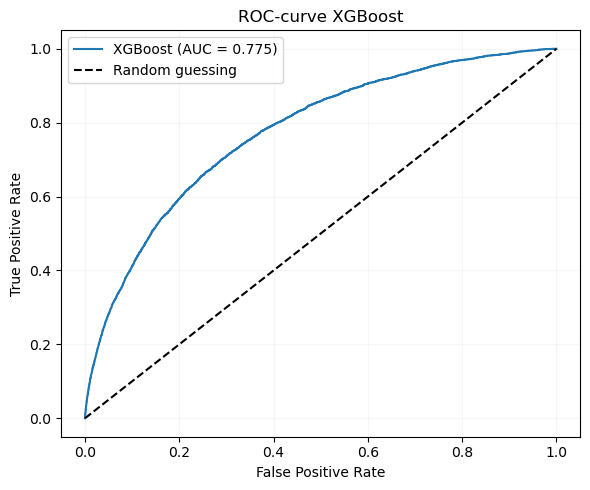

In [21]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-curve XGBoost')
plt.grid(alpha=0.1)
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
dt = DecisionTreeClassifier(max_depth=7, random_state=42, class_weight='balanced')
dt.fit(X_train_res, y_train_res)
dt_train_proba = dt.predict_proba(X_train_res)[:, 1].reshape(-1, 1)
dt_val_proba = dt.predict_proba(X_val_imp)[:, 1].reshape(-1, 1)
dt_test_proba = dt.predict_proba(X_test_imp)[:, 1].reshape(-1, 1)
X_train_aug = np.hstack([X_train_res, dt_train_proba])
X_val_aug = np.hstack([X_val_imp, dt_val_proba])
X_test_aug = np.hstack([X_test_imp, dt_test_proba])
gb_meta = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=5,
    min_samples_split=10, random_state=42
)
gb_meta.fit(X_train_aug, y_train_res)

GradientBoostingClassifier(max_depth=5, min_samples_split=10, n_estimators=200,
                           random_state=42)

In [28]:
def find_best_threshold(y_true, y_proba):
    thresholds = np.linspace(0.01, 0.99, 200)
    best_f1 = 0
    best_thr = 0.5
    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        f1 = f1_score(y_true, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
    return best_thr
stack_val_proba = gb_meta.predict_proba(X_val_aug)[:, 1]
thr_stack = find_best_threshold(y_val, stack_val_proba)
print('best threshold :', thr_stack)

best threshold : 0.16266331658291458


In [37]:
proba_stack = gb_meta.predict_proba(X_test_aug)[:, 1]
y_pred = (proba_stack >= thr_stack).astype(int)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, proba_stack)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.8495
Precision: 0.2525
Recall:    0.4409
F1-score:  0.3211
ROC-AUC:   0.7744


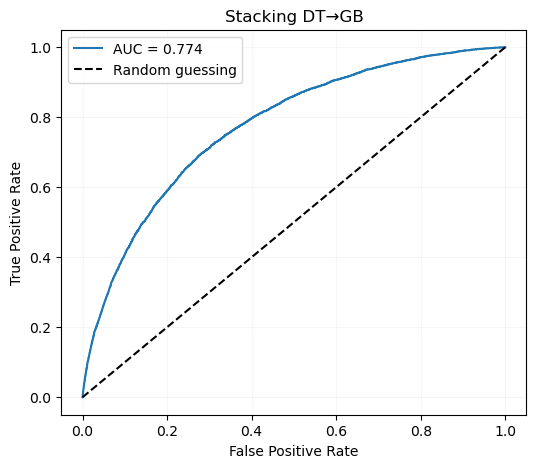

In [38]:
fpr, tpr, _ = roc_curve(y_test, proba_stack)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1], 'k--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Stacking DT→GB')
plt.legend()
plt.grid(alpha=0.1)
plt.show()